# Flood Emergency Response Priority Intelligence (FERPI) — Sri Lanka

**Machine Learning Assignment**

**Dataset:** Sri Lanka Flood Risk Dataset (25,000 records, 25 districts)

**Problem Statement:**
Most flood prediction systems only answer: *"Will it flood?"* This project goes further and answers: *"When a flood happens, which communities need emergency aid FIRST?"* We apply four distinct ML tasks — three supervised and one unsupervised — compare multiple algorithms per task with **5-fold cross-validation**, and combine their outputs into an **Emergency Resource Allocation Score (ERAS)**.

**Four Tasks (each with model comparison):**
| # | Task | Algorithms Compared | Type |
|---|------|-----------|------|
| 1 | Flood Occurrence Classification | Logistic Regression, Decision Tree, Random Forest, Hist Gradient Boosting | Supervised |
| 2 | Flood Risk Score Regression | Linear Regression, Decision Tree, Random Forest, Hist Gradient Boosting | Supervised |
| 3 | Habitation Suitability Classification | KNN, Decision Tree, Random Forest, Hist Gradient Boosting | Supervised |
| 4 | Flood Zone Segmentation | K-Means, Agglomerative Clustering | Unsupervised |

**Evaluation:** 80/20 train-test split + 5-fold cross-validation for robust model comparison.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.impute import SimpleImputer

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Regression models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

# Clustering models
from sklearn.cluster import KMeans, AgglomerativeClustering

# Metrics — Classification
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
# Metrics — Regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Metrics — Clustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Feature importance
from sklearn.inspection import permutation_importance

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
RANDOM_STATE = 42

print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv('sri_lanka_flood_risk_dataset_25000.csv')
print('Dataset Shape:', df.shape)
print('\nFirst 3 rows:')
df.head(3)

Dataset Shape: (25000, 32)

First 3 rows:


,record_id,district,place_name,latitude,longitude,elevation_m,distance_to_river_m,landcover,soil_type,water_supply,...,infrastructure_score,nearest_hospital_km,nearest_evac_km,flood_risk_score,flood_occurrence_current_event,inundation_area_sqm,is_good_to_live,reason_not_good_to_live,is_synthetic,generation_date
0,F100000,Kegalle,Kudagama,7.416887,81.789107,88,339.2,Wetland,Loamy,Municipal,...,12,2.76,2.74,39.56,No,0,No,Poor infrastructure,True,2025-06-02
1,F100001,Matara,Kiriwatta,6.266956,81.041369,58,1257.6,Agriculture,Clay,Municipal,...,46,1.61,8.45,30.64,No,0,Yes,NaN,True,2024-11-14
2,F100002,Trincomalee,Uduthota East,6.742164,80.927326,80,5225.3,Forest,Silty,Well,...,30,4.40,3.01,35.60,No,0,Yes,NaN,True,2024-03-01


In [3]:
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   record_id                       25000 non-null  object 
 1   district                        25000 non-null  object 
 2   place_name                      25000 non-null  object 
 3   latitude                        25000 non-null  float64
 4   longitude                       25000 non-null  float64
 5   elevation_m                     25000 non-null  int64  
 6   distance_to_river_m             25000 non-null  float64
 7   landcover                       25000 non-null  object 
 8   soil_type                       25000 non-null  object 
 9   water_supply                    25000 non-null  object 
 10  electricity                     24211 non-null  object 
 11  road_quality                    25000 non-null  object 
 12  population_

,latitude,longitude,elevation_m,distance_to_river_m,population_density_per_km2,built_up_percent,rainfall_7d_mm,monthly_rainfall_mm,drainage_index,ndvi,ndwi,historical_flood_count,infrastructure_score,nearest_hospital_km,nearest_evac_km,flood_risk_score,inundation_area_sqm
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.0,25000.00,25000.00,25000.00,25000.00
mean,7.92,80.77,187.51,2013.47,625.34,25.22,80.39,216.10,0.50,0.17,0.03,0.20,46.4,7.96,6.02,33.27,12234.62
std,1.17,0.65,323.41,2007.17,504.67,18.62,58.43,137.37,0.22,0.27,0.27,0.51,20.0,7.89,6.05,14.78,44147.11
min,5.90,79.65,0.00,0.00,10.00,1.00,0.00,0.00,0.00,-0.79,-1.00,0.00,5.0,0.00,0.00,0.00,0.00
25%,6.91,80.21,31.00,582.98,286.75,9.90,33.08,106.60,0.33,-0.02,-0.15,0.00,32.0,2.28,1.74,22.55,0.00
50%,7.92,80.76,68.00,1394.20,519.00,23.30,69.50,202.00,0.50,0.16,0.03,0.00,46.0,5.58,4.17,32.30,0.00
75%,8.93,81.33,124.00,2783.40,796.00,37.20,116.60,307.10,0.67,0.35,0.21,0.00,60.0,11.06,8.35,42.94,0.00
max,9.95,81.90,2148.00,16802.00,3113.00,95.00,372.20,863.70,1.00,1.00,1.00,5.00,95.0,75.71,55.95,100.00,312539.00


## 3. Exploratory Data Analysis (EDA)

In [4]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)

Columns with missing values:
electricity                  789
reason_not_good_to_live    18172
dtype: int64


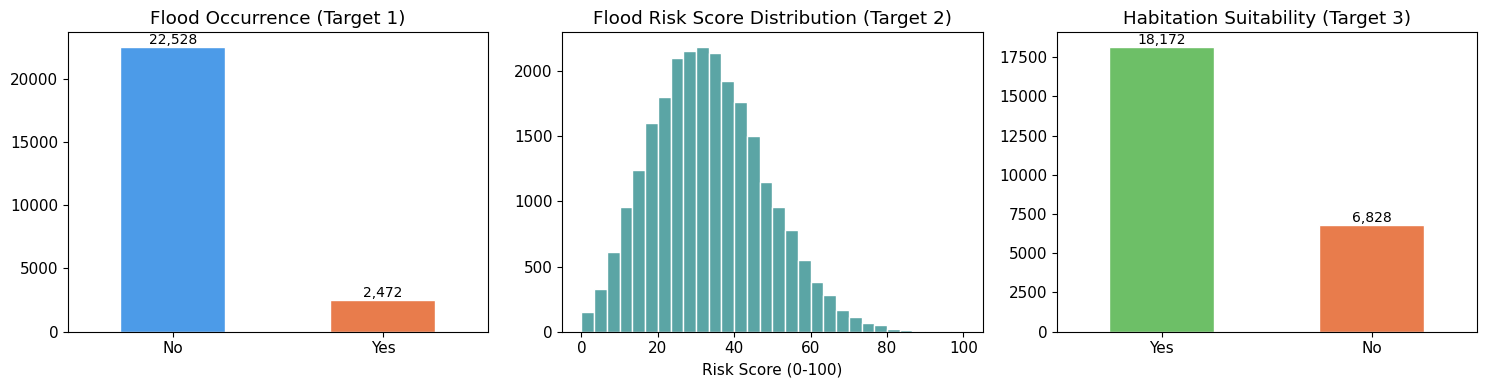

Note: Flood Occurrence is imbalanced (only ~10% Yes) — we will use F1-score and AUC-ROC


In [5]:
# Target variable distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Flood occurrence
df['flood_occurrence_current_event'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#4C9BE8','#E87C4C'], edgecolor='white'
)
axes[0].set_title('Flood Occurrence (Target 1)')
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Flood risk score
axes[1].hist(df['flood_risk_score'], bins=30, color='#5BA5A5', edgecolor='white')
axes[1].set_title('Flood Risk Score Distribution (Target 2)')
axes[1].set_xlabel('Risk Score (0-100)')

# Habitation suitability
df['is_good_to_live'].value_counts().plot(
    kind='bar', ax=axes[2], color=['#6DBF67','#E87C4C'], edgecolor='white'
)
axes[2].set_title('Habitation Suitability (Target 3)')
axes[2].set_xlabel('')
axes[2].tick_params(rotation=0)
for p in axes[2].patches:
    axes[2].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('target_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: Flood Occurrence is imbalanced (only ~10% Yes) — we will use F1-score and AUC-ROC')

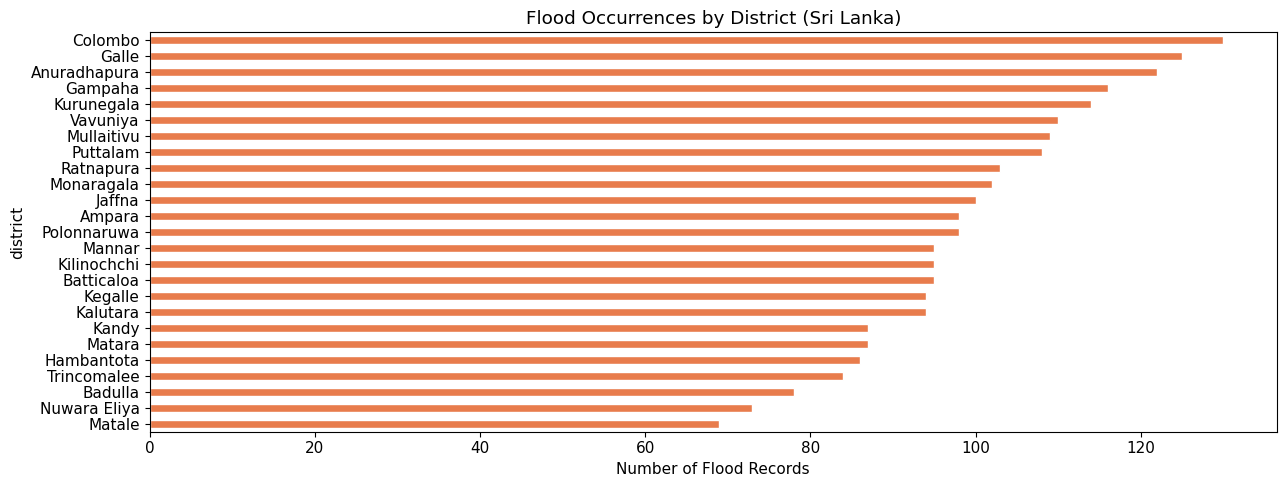

In [6]:
# Flood occurrences by district
district_flood = df[df['flood_occurrence_current_event']=='Yes']['district'].value_counts()
plt.figure(figsize=(13, 5))
district_flood.sort_values().plot(kind='barh', color='#E87C4C', edgecolor='white')
plt.title('Flood Occurrences by District (Sri Lanka)')
plt.xlabel('Number of Flood Records')
plt.tight_layout()
plt.savefig('flood_by_district.png', dpi=150, bbox_inches='tight')
plt.show()

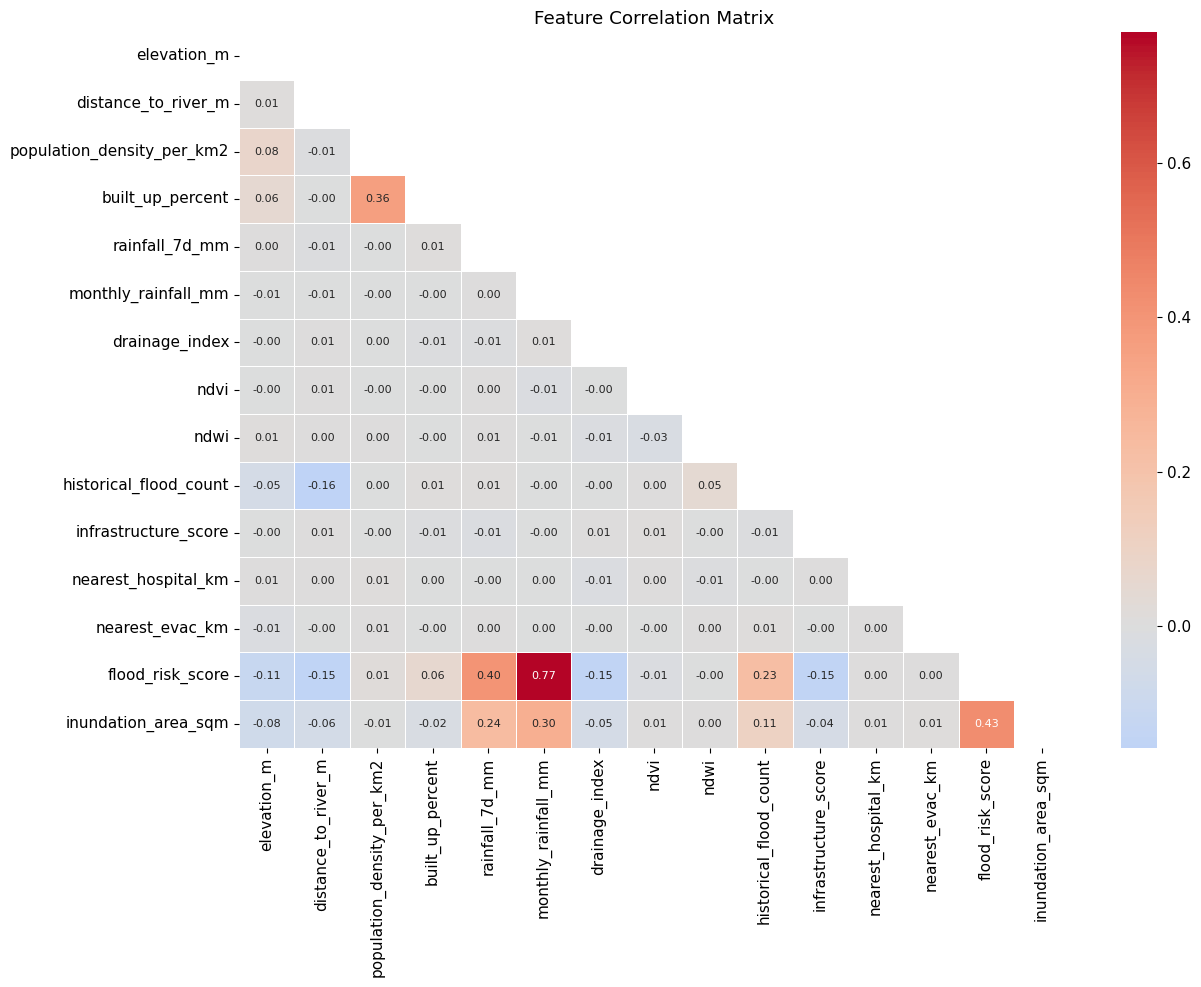

In [7]:
# Correlation heatmap of numerical features
num_cols = ['elevation_m','distance_to_river_m','population_density_per_km2',
            'built_up_percent','rainfall_7d_mm','monthly_rainfall_mm',
            'drainage_index','ndvi','ndwi','historical_flood_count',
            'infrastructure_score','nearest_hospital_km','nearest_evac_km',
            'flood_risk_score','inundation_area_sqm']
plt.figure(figsize=(13, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size':8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [8]:
# Drop columns not useful for ML
drop_cols = ['record_id', 'place_name', 'generation_date', 'is_synthetic',
             'reason_not_good_to_live', 'inundation_area_sqm']
df_ml = df.drop(columns=drop_cols).copy()

# Fill missing electricity with mode
df_ml['electricity'].fillna(df_ml['electricity'].mode()[0], inplace=True)

# Encode binary categorical columns
binary_map = {
    'flood_occurrence_current_event': {'Yes': 1, 'No': 0},
    'is_good_to_live': {'Yes': 1, 'No': 0},
    'water_presence_flag': {'Likely': 1, 'Unlikely': 0},
    'urban_rural': {'Urban': 1, 'Rural': 0}
}
for col, mapping in binary_map.items():
    df_ml[col] = df_ml[col].map(mapping)

# Label encode multi-class categorical columns
le = LabelEncoder()
cat_cols = ['district', 'landcover', 'soil_type', 'water_supply', 'electricity', 'road_quality']
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

print('Preprocessed dataset shape:', df_ml.shape)
print('\nData types after encoding:')
print(df_ml.dtypes)
print('\nNull values remaining:', df_ml.isnull().sum().sum())

Preprocessed dataset shape: (25000, 26)

Data types after encoding:
district                            int64
latitude                          float64
longitude                         float64
elevation_m                         int64
distance_to_river_m               float64
landcover                           int64
soil_type                           int64
water_supply                        int64
electricity                         int64
road_quality                        int64
population_density_per_km2          int64
built_up_percent                  float64
urban_rural                         int64
rainfall_7d_mm                    float64
monthly_rainfall_mm               float64
drainage_index                    float64
ndvi                              float64
ndwi                              float64
water_presence_flag                 int64
historical_flood_count              int64
infrastructure_score                int64
nearest_hospital_km               float64
nearest_

In [9]:
# Define feature set (23 features — used for all supervised tasks)
FEATURES = [
    'district', 'latitude', 'longitude', 'elevation_m', 'distance_to_river_m',
    'landcover', 'soil_type', 'water_supply', 'electricity', 'road_quality',
    'population_density_per_km2', 'built_up_percent', 'urban_rural',
    'rainfall_7d_mm', 'monthly_rainfall_mm', 'drainage_index',
    'ndvi', 'ndwi', 'water_presence_flag', 'historical_flood_count',
    'infrastructure_score', 'nearest_hospital_km', 'nearest_evac_km'
]

X = df_ml[FEATURES]
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURES)

print('Feature matrix shape:', X.shape)
print('Features used:', len(FEATURES))

Feature matrix shape: (25000, 23)
Features used: 23


## 5. Task 1 — Flood Occurrence Classification

**Target:** `flood_occurrence_current_event` (Yes=1 / No=0)

**Models compared:** Logistic Regression, Decision Tree, Random Forest, Hist Gradient Boosting

**Evaluation:** 80/20 stratified split + 5-fold stratified cross-validation

In [10]:
# Prepare data
y1 = df_ml['flood_occurrence_current_event']
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X_scaled, y1, test_size=0.2, random_state=RANDOM_STATE, stratify=y1
)
print(f'Train: {X1_train.shape[0]} | Test: {X1_test.shape[0]}')
print(f'Class balance in test — No: {(y1_test==0).sum()} | Yes: {(y1_test==1).sum()}')

Train: 20000 | Test: 5000
Class balance in test — No: 4506 | Yes: 494


In [11]:
# Define models
clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=500, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=RANDOM_STATE)
}

task1_results = {}
task1_models  = {}
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in clf_models.items():
    # Train/Test evaluation
    model.fit(X1_train, y1_train)
    y_pred  = model.predict(X1_test)
    y_proba = model.predict_proba(X1_test)[:,1]
    acc   = accuracy_score(y1_test, y_pred)
    f1    = f1_score(y1_test, y_pred, pos_label=1)
    auc   = roc_auc_score(y1_test, y_proba)
    
    # 5-Fold Cross-Validation
    cv_scores = cross_val_score(model, X_scaled, y1, cv=cv_strat, scoring='roc_auc')
    
    task1_results[name] = {
        'Accuracy': round(acc,4), 'F1-Score': round(f1,4), 'AUC-ROC': round(auc,4),
        'CV Mean': round(cv_scores.mean(),4), 'CV Std': round(cv_scores.std(),4)
    }
    task1_models[name] = model
    print(f'{name:<30} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  | CV={cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

# Dynamically select best model by AUC-ROC
best_t1 = max(task1_results, key=lambda k: task1_results[k]['AUC-ROC'])
best_auc1 = task1_results[best_t1]['AUC-ROC']
best_cv1 = task1_results[best_t1]['CV Mean']
print(f'\n*** Best Model: {best_t1} (AUC-ROC={best_auc1}, CV={best_cv1}) ***')

task1_df = pd.DataFrame(task1_results).T.reset_index()
task1_df.columns = ['Model', 'Accuracy', 'F1-Score', 'AUC-ROC', 'CV Mean', 'CV Std']
print('\n--- Task 1 Summary ---')
task1_df

Logistic Regression            Acc=0.8432  F1=0.5231  AUC=0.9308  | CV=0.9273 +/- 0.0022
Decision Tree                  Acc=0.8832  F1=0.6038  AUC=0.9160  | CV=0.9064 +/- 0.0132
Random Forest                  Acc=0.9074  F1=0.2844  AUC=0.9502  | CV=0.9488 +/- 0.0032
Hist Gradient Boosting         Acc=0.9186  F1=0.5684  AUC=0.9571  | CV=0.9570 +/- 0.0032

*** Best Model: Hist Gradient Boosting (AUC-ROC=0.9571, CV=0.957) ***

--- Task 1 Summary ---


,Model,Accuracy,F1-Score,AUC-ROC,CV Mean,CV Std
0,Logistic Regression,0.8432,0.5231,0.9308,0.9273,0.0022
1,Decision Tree,0.8832,0.6038,0.9160,0.9064,0.0132
2,Random Forest,0.9074,0.2844,0.9502,0.9488,0.0032
3,Hist Gradient Boosting,0.9186,0.5684,0.9571,0.9570,0.0032


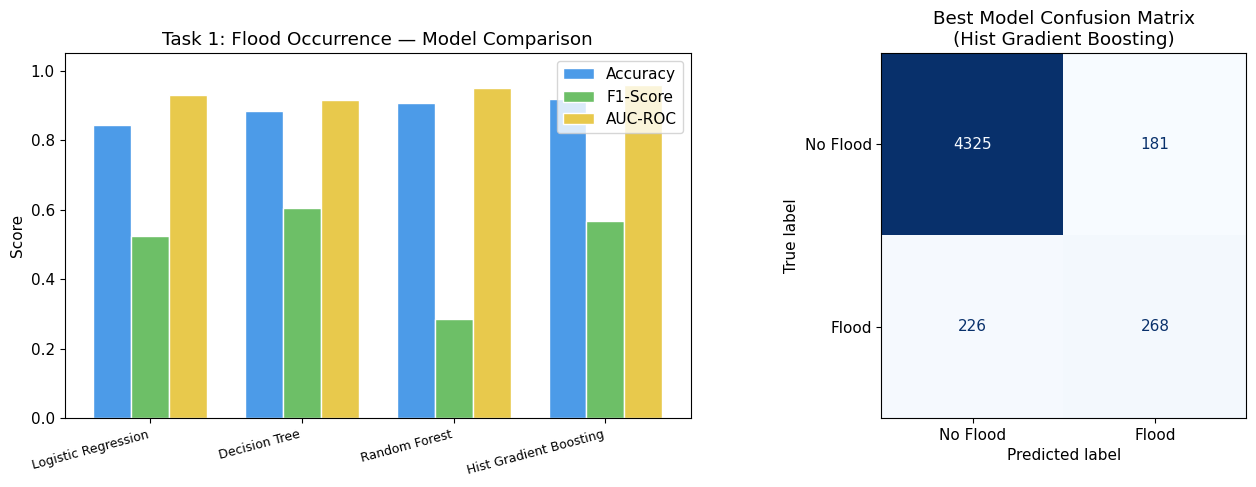

In [12]:
# Visualise comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(task1_df))
width = 0.25
colors = ['#4C9BE8', '#6DBF67', '#E8C94C']

for i, metric in enumerate(['Accuracy', 'F1-Score', 'AUC-ROC']):
    axes[0].bar(x + i*width, task1_df[metric], width, label=metric,
                color=colors[i], edgecolor='white')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(task1_df['Model'], rotation=15, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Task 1: Flood Occurrence — Model Comparison')
axes[0].legend()
axes[0].set_ylabel('Score')

# Confusion matrix for best model
best_clf1 = task1_models[best_t1]
y_pred_best = best_clf1.predict(X1_test)
cm = confusion_matrix(y1_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['No Flood','Flood']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Best Model Confusion Matrix\n({best_t1})')

plt.tight_layout()
plt.savefig('task1_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Classification report for best model
print(f'=== Classification Report — {best_t1} (Best) ===')
print(classification_report(y1_test, y_pred_best, target_names=['No Flood','Flood']))

=== Classification Report — Hist Gradient Boosting (Best) ===
              precision    recall  f1-score   support

    No Flood       0.95      0.96      0.96      4506
       Flood       0.60      0.54      0.57       494

    accuracy                           0.92      5000
   macro avg       0.77      0.75      0.76      5000
weighted avg       0.92      0.92      0.92      5000



## 6. Task 2 — Flood Risk Score Regression

**Target:** `flood_risk_score` (continuous 0–100)

**Models compared:** Linear Regression, Decision Tree Regressor, Random Forest Regressor, Hist Gradient Boosting Regressor

**Evaluation:** 80/20 split + 5-fold cross-validation

In [14]:
# Prepare data
y2 = df_ml['flood_risk_score']
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_scaled, y2, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train: {X2_train.shape[0]} | Test: {X2_test.shape[0]}')

Train: 20000 | Test: 5000


In [15]:
# Define regression models
reg_models = {
    'Linear Regression':             LinearRegression(),
    'Decision Tree Regressor':       DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    'Random Forest Regressor':       RandomForestRegressor(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1),
    'Hist Gradient Boosting':        HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, random_state=RANDOM_STATE)
}

task2_results = {}
task2_models  = {}
cv_kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in reg_models.items():
    model.fit(X2_train, y2_train)
    y_pred = model.predict(X2_test)
    rmse   = np.sqrt(mean_squared_error(y2_test, y_pred))
    mae    = mean_absolute_error(y2_test, y_pred)
    r2     = r2_score(y2_test, y_pred)
    
    # 5-Fold Cross-Validation
    cv_scores = cross_val_score(model, X_scaled, y2, cv=cv_kf, scoring='r2')
    
    task2_results[name] = {
        'RMSE': round(rmse,4), 'MAE': round(mae,4), 'R2 Score': round(r2,4),
        'CV Mean': round(cv_scores.mean(),4), 'CV Std': round(cv_scores.std(),4)
    }
    task2_models[name] = model
    print(f'{name:<30} RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}  | CV R2={cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

best_t2 = max(task2_results, key=lambda k: task2_results[k]['R2 Score'])
best_r2 = task2_results[best_t2]['R2 Score']
best_cv2 = task2_results[best_t2]['CV Mean']
print(f'\n*** Best Model: {best_t2} (R2={best_r2}, CV={best_cv2}) ***')

task2_df = pd.DataFrame(task2_results).T.reset_index()
task2_df.columns = ['Model', 'RMSE', 'MAE', 'R2 Score', 'CV Mean', 'CV Std']
print('\n--- Task 2 Summary ---')
task2_df

Linear Regression              RMSE=5.4151  MAE=4.5301  R2=0.8622  | CV R2=0.8687 +/- 0.0041
Decision Tree Regressor        RMSE=3.7440  MAE=2.8965  R2=0.9341  | CV R2=0.9364 +/- 0.0017
Random Forest Regressor        RMSE=2.1544  MAE=1.5991  R2=0.9782  | CV R2=0.9789 +/- 0.0007
Hist Gradient Boosting         RMSE=0.9446  MAE=0.6926  R2=0.9958  | CV R2=0.9952 +/- 0.0003

*** Best Model: Hist Gradient Boosting (R2=0.9958, CV=0.9952) ***

--- Task 2 Summary ---


,Model,RMSE,MAE,R2 Score,CV Mean,CV Std
0,Linear Regression,5.4151,4.5301,0.8622,0.8687,0.0041
1,Decision Tree Regressor,3.7440,2.8965,0.9341,0.9364,0.0017
2,Random Forest Regressor,2.1544,1.5991,0.9782,0.9789,0.0007
3,Hist Gradient Boosting,0.9446,0.6926,0.9958,0.9952,0.0003


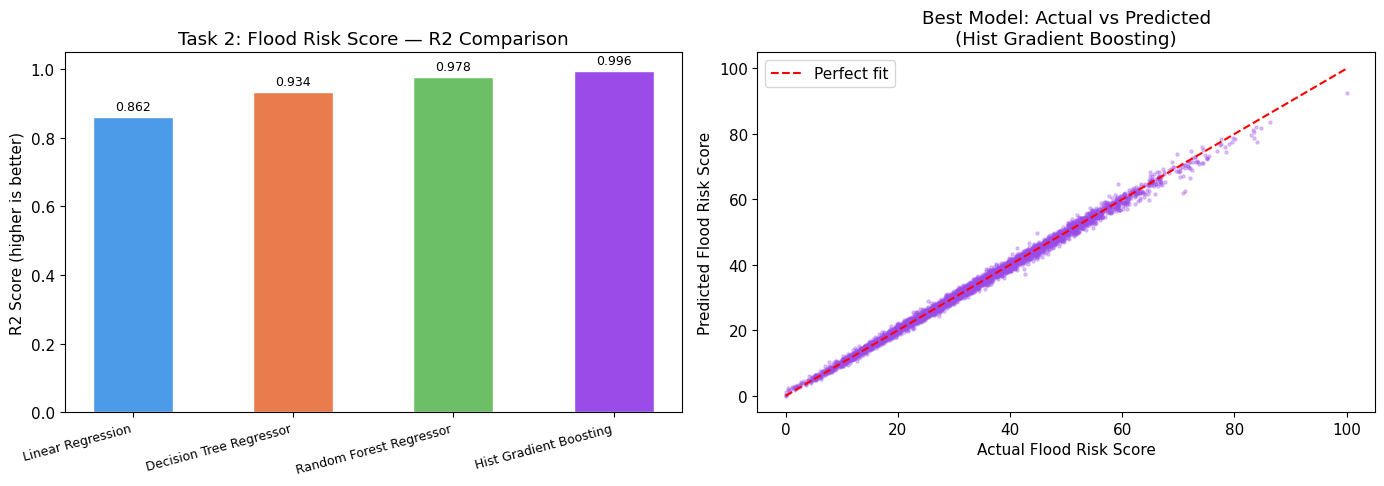

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 comparison bar chart
x = np.arange(len(task2_df))
bars = axes[0].bar(x, task2_df['R2 Score'],
                   color=['#4C9BE8','#E87C4C','#6DBF67','#9B4CE8'],
                   edgecolor='white', width=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(task2_df['Model'], rotation=15, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Task 2: Flood Risk Score — R2 Comparison')
axes[0].set_ylabel('R2 Score (higher is better)')
for bar, val in zip(bars, task2_df['R2 Score']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Actual vs Predicted scatter for best model
best_reg = task2_models[best_t2]
y2_pred_best = best_reg.predict(X2_test)
axes[1].scatter(y2_test, y2_pred_best, alpha=0.3, s=5, color='#9B4CE8')
axes[1].plot([0,100],[0,100], 'r--', lw=1.5, label='Perfect fit')
axes[1].set_xlabel('Actual Flood Risk Score')
axes[1].set_ylabel('Predicted Flood Risk Score')
axes[1].set_title(f'Best Model: Actual vs Predicted\n({best_t2})')
axes[1].legend()

plt.tight_layout()
plt.savefig('task2_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Task 3 — Habitation Suitability Classification

**Target:** `is_good_to_live` (Yes=1 / No=0)

**Models compared:** KNN, Decision Tree, Random Forest, Hist Gradient Boosting

**Note:** Uses the same 23 environmental/infrastructure features as Tasks 1 & 2. The `flood_risk_score` column is **excluded** from features to prevent data leakage (it may be deterministically derived from the target in synthetic data).

**Evaluation:** 80/20 stratified split + 5-fold stratified cross-validation

In [17]:
# Prepare data — same features as Tasks 1 & 2 (no flood_risk_score to avoid leakage)
y3 = df_ml['is_good_to_live']
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X_scaled, y3, test_size=0.2, random_state=RANDOM_STATE, stratify=y3
)
print(f'Train: {X3_train.shape[0]} | Test: {X3_test.shape[0]}')
print(f'Class balance — Yes: {(y3_test==1).sum()} | No: {(y3_test==0).sum()}')

Train: 20000 | Test: 5000
Class balance — Yes: 3634 | No: 1366


In [18]:
clf3_models = {
    'KNN (k=7)':              KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'Decision Tree':          DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    'Random Forest':          RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=RANDOM_STATE)
}

task3_results = {}
task3_models  = {}
cv_strat3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in clf3_models.items():
    model.fit(X3_train, y3_train)
    y_pred  = model.predict(X3_test)
    y_proba = model.predict_proba(X3_test)[:,1]
    acc  = accuracy_score(y3_test, y_pred)
    f1   = f1_score(y3_test, y_pred)
    auc  = roc_auc_score(y3_test, y_proba)
    
    # 5-Fold Cross-Validation
    cv_scores = cross_val_score(model, X_scaled, y3, cv=cv_strat3, scoring='roc_auc')
    
    task3_results[name] = {
        'Accuracy': round(acc,4), 'F1-Score': round(f1,4), 'AUC-ROC': round(auc,4),
        'CV Mean': round(cv_scores.mean(),4), 'CV Std': round(cv_scores.std(),4)
    }
    task3_models[name] = model
    print(f'{name:<30} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  | CV={cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

best_t3 = max(task3_results, key=lambda k: task3_results[k]['AUC-ROC'])
best_auc3 = task3_results[best_t3]['AUC-ROC']
best_cv3 = task3_results[best_t3]['CV Mean']
print(f'\n*** Best Model: {best_t3} (AUC-ROC={best_auc3}, CV={best_cv3}) ***')

task3_df = pd.DataFrame(task3_results).T.reset_index()
task3_df.columns = ['Model', 'Accuracy', 'F1-Score', 'AUC-ROC', 'CV Mean', 'CV Std']
print('\n--- Task 3 Summary ---')
task3_df

KNN (k=7)                      Acc=0.8034  F1=0.8774  AUC=0.8378  | CV=0.8441 +/- 0.0032
Decision Tree                  Acc=0.9818  F1=0.9875  AUC=0.9874  | CV=0.9894 +/- 0.0026
Random Forest                  Acc=0.9832  F1=0.9886  AUC=0.9990  | CV=0.9987 +/- 0.0002
Hist Gradient Boosting         Acc=0.9928  F1=0.9951  AUC=0.9998  | CV=0.9997 +/- 0.0001

*** Best Model: Hist Gradient Boosting (AUC-ROC=0.9998, CV=0.9997) ***

--- Task 3 Summary ---


,Model,Accuracy,F1-Score,AUC-ROC,CV Mean,CV Std
0,KNN (k=7),0.8034,0.8774,0.8378,0.8441,0.0032
1,Decision Tree,0.9818,0.9875,0.9874,0.9894,0.0026
2,Random Forest,0.9832,0.9886,0.9990,0.9987,0.0002
3,Hist Gradient Boosting,0.9928,0.9951,0.9998,0.9997,0.0001


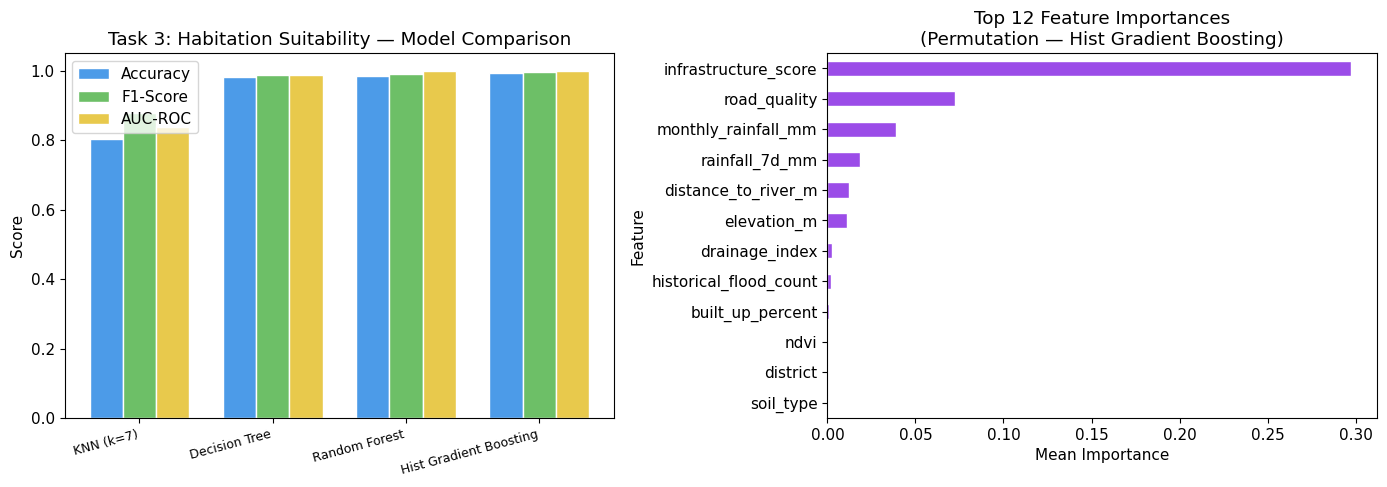

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(task3_df))
width = 0.25
colors = ['#4C9BE8', '#6DBF67', '#E8C94C']
for i, metric in enumerate(['Accuracy', 'F1-Score', 'AUC-ROC']):
    axes[0].bar(x + i*width, task3_df[metric], width, label=metric,
                color=colors[i], edgecolor='white')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(task3_df['Model'], rotation=15, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Task 3: Habitation Suitability — Model Comparison')
axes[0].legend()
axes[0].set_ylabel('Score')

# Feature importance of best model
best_clf3 = task3_models[best_t3]
perm_imp = permutation_importance(best_clf3, X3_test, y3_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
feat_imp_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': perm_imp.importances_mean
}).sort_values('Importance', ascending=True).tail(12)
feat_imp_df.plot(kind='barh', x='Feature', y='Importance', ax=axes[1],
                 color='#9B4CE8', edgecolor='white', legend=False)
axes[1].set_title(f'Top 12 Feature Importances\n(Permutation — {best_t3})')
axes[1].set_xlabel('Mean Importance')

plt.tight_layout()
plt.savefig('task3_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Task 4 — Flood Zone Segmentation (Unsupervised)

**Objective:** Segment all locations into strategic flood response zones using clustering.

**Models compared:** K-Means, Agglomerative Clustering

**Best K selection:** Elbow Method + Silhouette Score

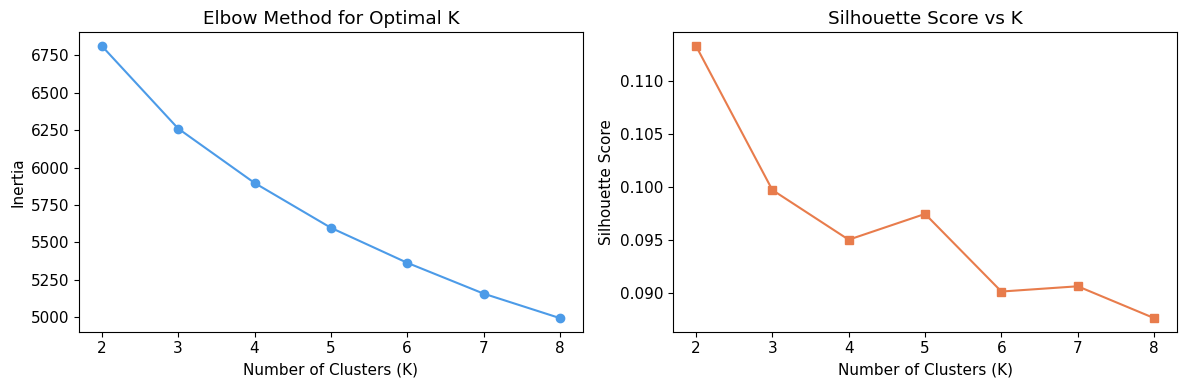

Optimal K = 2 (highest silhouette score = 0.1133)


In [20]:
# Select features for clustering (flood-relevant)
CLUSTER_FEATURES = [
    'flood_risk_score', 'elevation_m', 'distance_to_river_m',
    'rainfall_7d_mm', 'monthly_rainfall_mm', 'ndwi', 'ndvi',
    'infrastructure_score', 'population_density_per_km2',
    'nearest_hospital_km', 'nearest_evac_km', 'drainage_index',
    'historical_flood_count'
]

X_cluster = df_ml[CLUSTER_FEATURES].copy()
X_cluster_scaled = MinMaxScaler().fit_transform(X_cluster)

# --- Find optimal K using Elbow + Silhouette ---
k_range = range(2, 9)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels, sample_size=3000))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, 'o-', color='#4C9BE8')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal K')
axes[1].plot(list(k_range), silhouettes, 's-', color='#E87C4C')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(k_range)[np.argmax(silhouettes)]
print(f'Optimal K = {best_k} (highest silhouette score = {max(silhouettes):.4f})')

In [21]:
# Run both clustering algorithms with best K
OPTIMAL_K = best_k

km_model = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
km_labels = km_model.fit_predict(X_cluster_scaled)

agg_model = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels = agg_model.fit_predict(X_cluster_scaled)

km_sil  = silhouette_score(X_cluster_scaled, km_labels, sample_size=3000)
agg_sil = silhouette_score(X_cluster_scaled, agg_labels, sample_size=3000)
km_ch   = calinski_harabasz_score(X_cluster_scaled, km_labels)
agg_ch  = calinski_harabasz_score(X_cluster_scaled, agg_labels)

task4_df = pd.DataFrame({
    'Model': ['K-Means', 'Agglomerative Clustering'],
    'Silhouette Score': [round(km_sil,4), round(agg_sil,4)],
    'Calinski-Harabasz': [round(km_ch,1), round(agg_ch,1)]
})
print(task4_df.to_string(index=False))

# Select best by Silhouette Score (primary metric for cluster quality)
if agg_sil > km_sil:
    best_labels = agg_labels
    best_t4 = 'Agglomerative Clustering'
    best_sil = agg_sil
else:
    best_labels = km_labels
    best_t4 = 'K-Means'
    best_sil = km_sil

df_ml['zone'] = best_labels
print(f'\n*** Best Clustering: {best_t4} (Silhouette = {best_sil:.4f}) ***')

                   Model  Silhouette Score  Calinski-Harabasz
                 K-Means            0.1135             3310.6
Agglomerative Clustering            0.1381             1616.5

*** Best Clustering: Agglomerative Clustering (Silhouette = 0.1381) ***


In [22]:
# Profile each zone
zone_profile = df_ml.groupby('zone')[['flood_risk_score','infrastructure_score',
                                       'population_density_per_km2',
                                       'nearest_hospital_km',
                                       'nearest_evac_km']].mean().round(2)
zone_profile = zone_profile.sort_values('flood_risk_score', ascending=False)
zone_profile.index = [f'Zone {i+1}' for i in range(len(zone_profile))]
print('=== Flood Response Zone Profiles ===')
print(zone_profile)

=== Flood Response Zone Profiles ===
        flood_risk_score  infrastructure_score  population_density_per_km2  \
Zone 1             33.77                 46.40                      615.48   
Zone 2             29.72                 46.37                      695.34   

        nearest_hospital_km  nearest_evac_km  
Zone 1                 7.98             6.06  
Zone 2                 7.86             5.76  


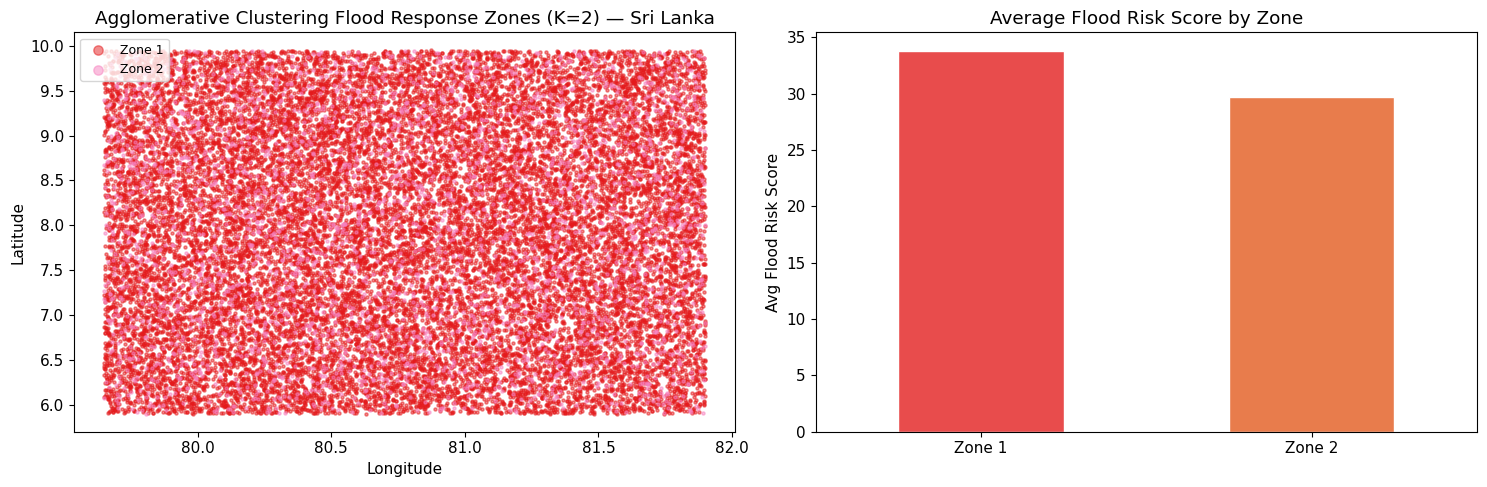

In [23]:
# Visualise zones on lat/lon scatter
df_plot = df.copy()
df_plot['zone'] = best_labels

zone_colors = plt.cm.Set1(np.linspace(0, 0.8, OPTIMAL_K))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for z in range(OPTIMAL_K):
    mask = df_plot['zone'] == z
    axes[0].scatter(df_plot[mask]['longitude'], df_plot[mask]['latitude'],
                    s=5, alpha=0.5, color=zone_colors[z], label=f'Zone {z+1}')
axes[0].set_title(f'{best_t4} Flood Response Zones (K={OPTIMAL_K}) — Sri Lanka')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].legend(markerscale=3, fontsize=9)

# Zone comparison bar chart
zone_profile['flood_risk_score'].plot(kind='bar', ax=axes[1],
                                       color=['#E84C4C','#E87C4C','#E8C94C','#6DBF67'],
                                       edgecolor='white')
axes[1].set_title('Average Flood Risk Score by Zone')
axes[1].set_ylabel('Avg Flood Risk Score')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig('task4_zones.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Novel Contribution — Emergency Resource Allocation Score (ERAS)

We combine outputs from all 4 tasks to generate an **ERAS score** per location.  
Higher ERAS = that location needs emergency flood aid sooner.

**Formula:**
```
ERAS = 0.35 x Predicted_Flood_Risk_Score (normalised)
     + 0.25 x Flood_Probability (from Task 1)
     + 0.20 x Habitation_Vulnerability (1 - P(good_to_live) from Task 3)
     + 0.20 x Zone_Risk_Rank (from Task 4, normalised)
```

In [24]:
# Get predictions from dynamically selected best models on full dataset
X_full_scaled = pd.DataFrame(scaler.fit_transform(df_ml[FEATURES]), columns=FEATURES)

print(f'Best models used for ERAS:')
print(f'  Task 1 (Flood Probability):    {best_t1}')
print(f'  Task 2 (Risk Score):           {best_t2}')
print(f'  Task 3 (Vulnerability):        {best_t3}')
print(f'  Task 4 (Zone Clustering):      {best_t4}')

# Task 1: Flood probability
flood_prob = task1_models[best_t1].predict_proba(X_full_scaled)[:,1]

# Task 2: Predicted flood risk score (normalise 0-1)
pred_risk = task2_models[best_t2].predict(X_full_scaled)
pred_risk_norm = (pred_risk - pred_risk.min()) / (pred_risk.max() - pred_risk.min())

# Task 3: Vulnerability = 1 - P(good_to_live)
good_prob = task3_models[best_t3].predict_proba(X_full_scaled)[:,1]
vulnerability = 1 - good_prob

# Task 4: Zone risk rank (normalised)
zone_risk_rank = df_ml['zone'].map(
    dict(zip(range(OPTIMAL_K),
             MinMaxScaler().fit_transform(
                 df_ml.groupby('zone')['flood_risk_score'].mean()
                 .sort_values().values.reshape(-1,1)).flatten()
            ))
).values

# Compute ERAS
ERAS = (0.35 * pred_risk_norm +
        0.25 * flood_prob +
        0.20 * vulnerability +
        0.20 * zone_risk_rank)

df_result = df[['record_id','district','place_name','latitude','longitude']].copy()
df_result['ERAS_Score']          = ERAS.round(4)
df_result['Flood_Probability']   = flood_prob.round(4)
df_result['Predicted_Risk_Score']= pred_risk.round(2)
df_result['Vulnerability']       = vulnerability.round(4)
df_result['Zone']                = best_labels

print('\n=== Top 15 Highest Priority Locations (ERAS) ===')
df_result.sort_values('ERAS_Score', ascending=False).head(15)[[
    'district','place_name','ERAS_Score','Flood_Probability','Predicted_Risk_Score','Zone'
]]

Best models used for ERAS:
  Task 1 (Flood Probability):    Hist Gradient Boosting
  Task 2 (Risk Score):           Hist Gradient Boosting
  Task 3 (Vulnerability):        Hist Gradient Boosting
  Task 4 (Zone Clustering):      Agglomerative Clustering

=== Top 15 Highest Priority Locations (ERAS) ===


,district,place_name,ERAS_Score,Flood_Probability,Predicted_Risk_Score,Zone
22399,Nuwara Eliya,Polanuwara West,0.9016,0.8043,80.87,1
24450,Badulla,Udupitiya,0.8886,0.6696,86.49,1
15859,Nuwara Eliya,Pahalamulla Central,0.8750,0.6545,83.87,1
19203,Matale,Udaramulla,0.8709,0.8304,70.82,1
5092,Nuwara Eliya,Panavila West,0.8687,0.8069,72.64,1
21054,Matale,Udaragama Central,0.8678,0.8963,65.46,1
16492,Matale,Udaramulla South,0.8644,0.8625,66.83,1
1526,Badulla,Nayakumbura West,0.8608,0.7285,74.95,1
9080,Badulla,Kudamedura South,0.8512,0.7706,70.30,1
16271,Matale,Uduwatta Central,0.8466,0.8260,65.59,1


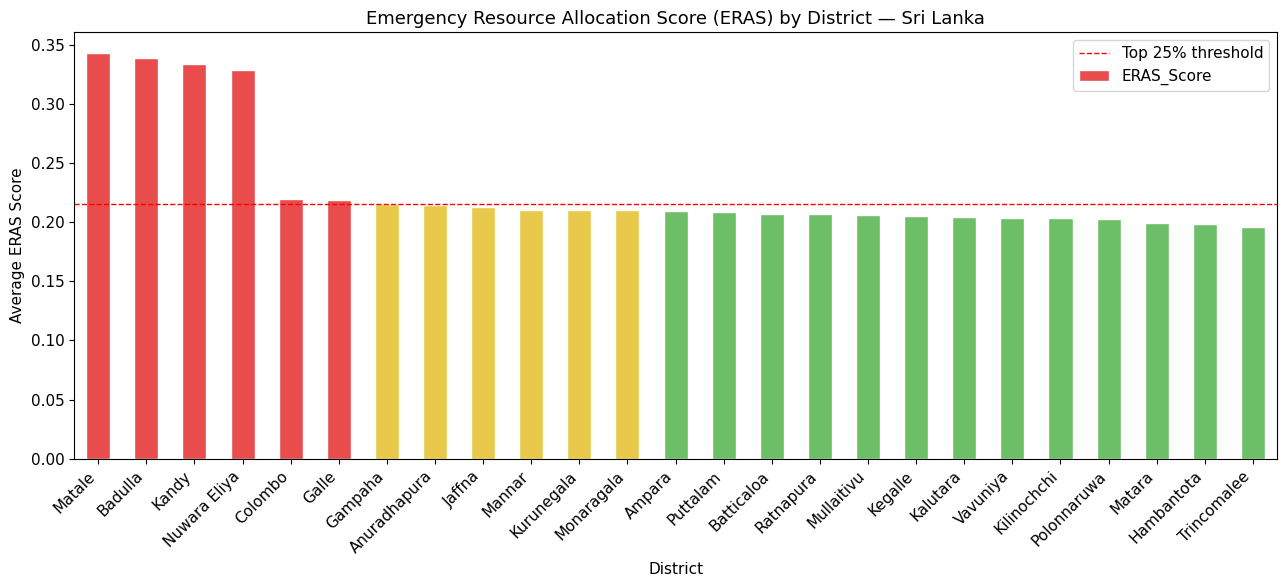


Top 5 highest priority districts:
district
Matale          0.343148
Badulla         0.338206
Kandy           0.333255
Nuwara Eliya    0.328700
Colombo         0.219607
Name: ERAS_Score, dtype: float64


In [25]:
# District-level ERAS aggregation
district_eras = df_result.groupby('district')['ERAS_Score'].mean().sort_values(ascending=False)

plt.figure(figsize=(13, 6))
colors_eras = ['#E84C4C' if v > district_eras.quantile(0.75)
               else '#E8C94C' if v > district_eras.quantile(0.5)
               else '#6DBF67' for v in district_eras]
district_eras.plot(kind='bar', color=colors_eras, edgecolor='white')
plt.title('Emergency Resource Allocation Score (ERAS) by District — Sri Lanka', fontsize=13)
plt.xlabel('District')
plt.ylabel('Average ERAS Score')
plt.xticks(rotation=45, ha='right')
plt.axhline(district_eras.quantile(0.75), color='red', linestyle='--',
             linewidth=1, label='Top 25% threshold')
plt.legend()
plt.tight_layout()
plt.savefig('eras_by_district.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 highest priority districts:')
print(district_eras.head(5))

## 10. Final Results Comparison

Summary comparing all models across all tasks — with **5-fold cross-validation** results.

In [26]:
print('='*80)
print('TASK 1 — Flood Occurrence Classification')
print('='*80)
print(task1_df.to_string(index=False))
print(f'\n  *** Best: {best_t1} | AUC-ROC = {best_auc1} | CV = {best_cv1} ***')

print('\n'+'='*80)
print('TASK 2 — Flood Risk Score Regression')
print('='*80)
print(task2_df.to_string(index=False))
print(f'\n  *** Best: {best_t2} | R2 = {best_r2} | CV = {best_cv2} ***')

print('\n'+'='*80)
print('TASK 3 — Habitation Suitability Classification')
print('='*80)
print(task3_df.to_string(index=False))
print(f'\n  *** Best: {best_t3} | AUC-ROC = {best_auc3} | CV = {best_cv3} ***')

print('\n'+'='*80)
print('TASK 4 — Zone Clustering (Unsupervised)')
print('='*80)
print(task4_df.to_string(index=False))
print(f'\n  *** Best: {best_t4} | Silhouette = {best_sil:.4f} ***')

print('\n'+'='*80)
print('NOVEL CONTRIBUTION — Emergency Resource Allocation Score (ERAS)')
print('='*80)
print(f'  ERAS combines all 4 model outputs into a single priority score.')
print(f'  Total locations scored: {len(df_result)}')
print(f'  ERAS range: {ERAS.min():.4f} to {ERAS.max():.4f}')
top_district = district_eras.index[0]
print(f'  Highest priority district: {top_district}')

TASK 1 — Flood Occurrence Classification
                 Model  Accuracy  F1-Score  AUC-ROC  CV Mean  CV Std
   Logistic Regression    0.8432    0.5231   0.9308   0.9273  0.0022
         Decision Tree    0.8832    0.6038   0.9160   0.9064  0.0132
         Random Forest    0.9074    0.2844   0.9502   0.9488  0.0032
Hist Gradient Boosting    0.9186    0.5684   0.9571   0.9570  0.0032

  *** Best: Hist Gradient Boosting | AUC-ROC = 0.9571 | CV = 0.957 ***

TASK 2 — Flood Risk Score Regression
                  Model   RMSE    MAE  R2 Score  CV Mean  CV Std
      Linear Regression 5.4151 4.5301    0.8622   0.8687  0.0041
Decision Tree Regressor 3.7440 2.8965    0.9341   0.9364  0.0017
Random Forest Regressor 2.1544 1.5991    0.9782   0.9789  0.0007
 Hist Gradient Boosting 0.9446 0.6926    0.9958   0.9952  0.0003

  *** Best: Hist Gradient Boosting | R2 = 0.9958 | CV = 0.9952 ***

TASK 3 — Habitation Suitability Classification
                 Model  Accuracy  F1-Score  AUC-ROC  CV Mean  C

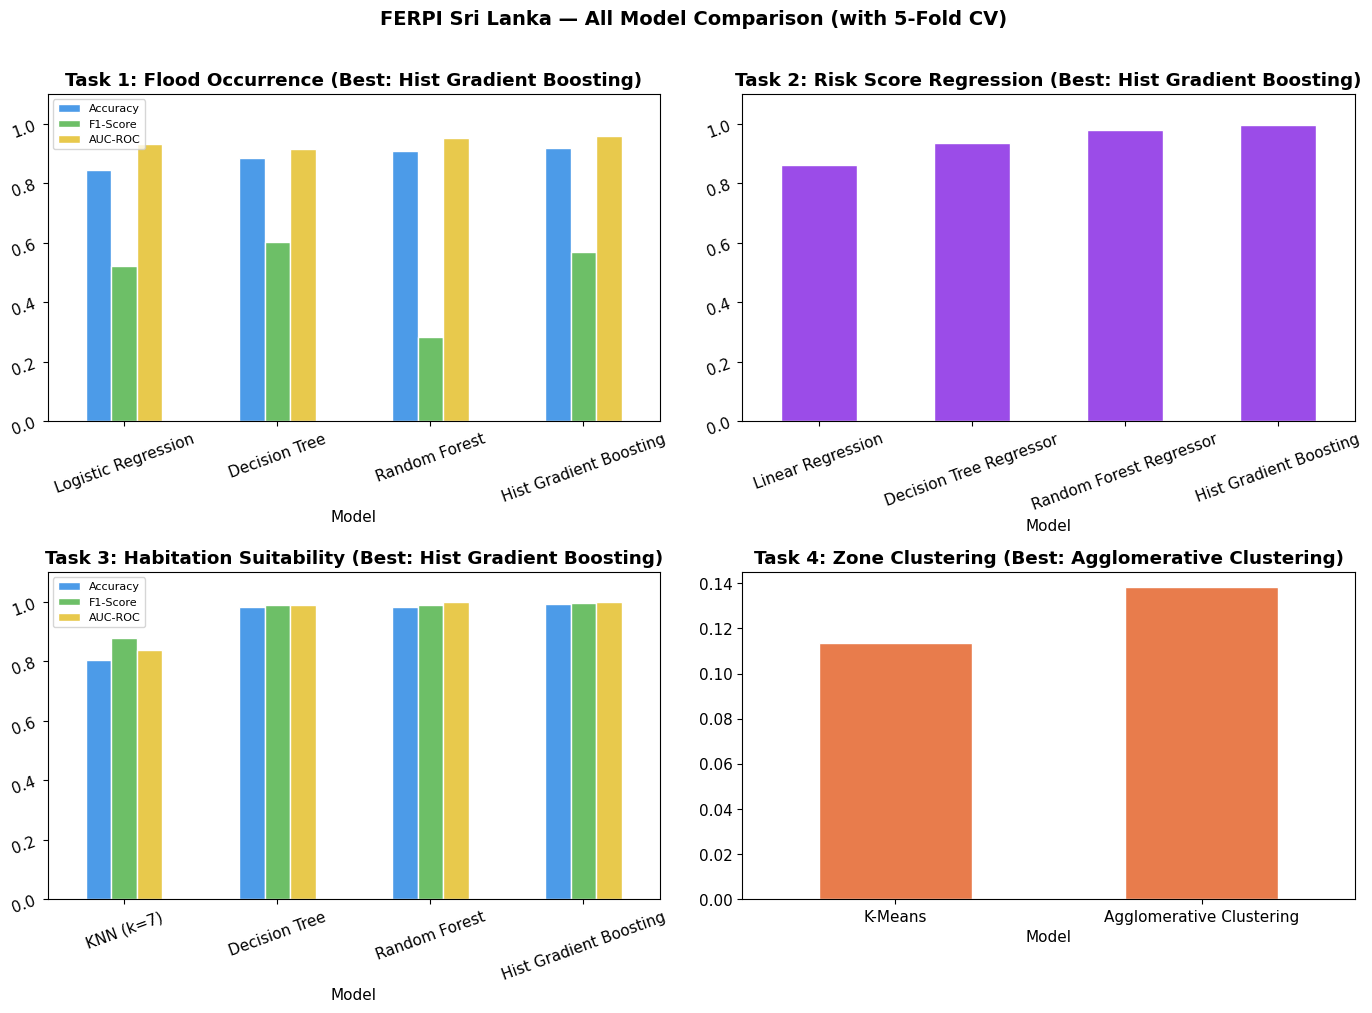


All tasks complete. Notebook ready for submission.


In [27]:
# Final master comparison chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Task 1
task1_df.set_index('Model')[['Accuracy','F1-Score','AUC-ROC']].plot(
    kind='bar', ax=axes[0,0], color=['#4C9BE8','#6DBF67','#E8C94C'], edgecolor='white')
axes[0,0].set_title(f'Task 1: Flood Occurrence (Best: {best_t1})', fontweight='bold')
axes[0,0].set_ylim(0, 1.1); axes[0,0].tick_params(rotation=20); axes[0,0].legend(fontsize=8)

# Task 2
task2_df.set_index('Model')[['R2 Score']].plot(
    kind='bar', ax=axes[0,1], color='#9B4CE8', edgecolor='white', legend=False)
axes[0,1].set_title(f'Task 2: Risk Score Regression (Best: {best_t2})', fontweight='bold')
axes[0,1].set_ylim(0, 1.1); axes[0,1].tick_params(rotation=20)

# Task 3
task3_df.set_index('Model')[['Accuracy','F1-Score','AUC-ROC']].plot(
    kind='bar', ax=axes[1,0], color=['#4C9BE8','#6DBF67','#E8C94C'], edgecolor='white')
axes[1,0].set_title(f'Task 3: Habitation Suitability (Best: {best_t3})', fontweight='bold')
axes[1,0].set_ylim(0, 1.1); axes[1,0].tick_params(rotation=20); axes[1,0].legend(fontsize=8)

# Task 4
task4_df.set_index('Model')[['Silhouette Score']].plot(
    kind='bar', ax=axes[1,1], color='#E87C4C', edgecolor='white', legend=False)
axes[1,1].set_title(f'Task 4: Zone Clustering (Best: {best_t4})', fontweight='bold')
axes[1,1].tick_params(rotation=0)

plt.suptitle('FERPI Sri Lanka — All Model Comparison (with 5-Fold CV)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAll tasks complete. Notebook ready for submission.')